In [112]:
import json

import gc_utils
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, ScalarFormatter

In [113]:
sim = "m12i"
sim_dir = "/Users/z5114326/Documents/simulations/"
# sim_dir = "/Volumes/Expansion/simulations/"

sim_codes = sim_dir + "simulation_codes.json"
with open(sim_codes) as sim_json:
    sim_data = json.load(sim_json)

In [114]:
it_min = 0
it_max = 100

proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
proc_data = h5py.File(proc_file, "r")  # open processed data file

in_et_norm = np.array([])
in_jr = np.array([])
in_jp = np.array([])
in_jz = np.array([])

ex_et_norm = np.array([])
ex_jr = np.array([])
ex_jp = np.array([])
ex_jz = np.array([])

for it in range(it_min, it_max + 1):
    it_id = gc_utils.iteration_name(it)
    snp_dat = proc_data[it_id]["snapshots"]["snap600"]
    grp_msk = snp_dat["group_id"][()] == 0

    in_et_norm = np.concatenate((in_et_norm, snp_dat["et_norm"][grp_msk]))
    in_jr = np.concatenate((in_jr, snp_dat["j.cyl"][:, 0][grp_msk]))
    in_jp = np.concatenate((in_jp, snp_dat["j.cyl"][:, 1][grp_msk]))
    in_jz = np.concatenate((in_jz, snp_dat["j.cyl"][:, 2][grp_msk]))

    ex_et_norm = np.concatenate((ex_et_norm, snp_dat["et_norm"][~grp_msk]))
    ex_jr = np.concatenate((ex_jr, snp_dat["j.cyl"][:, 0][~grp_msk]))
    ex_jp = np.concatenate((ex_jp, snp_dat["j.cyl"][:, 1][~grp_msk]))
    ex_jz = np.concatenate((ex_jz, snp_dat["j.cyl"][:, 2][~grp_msk]))

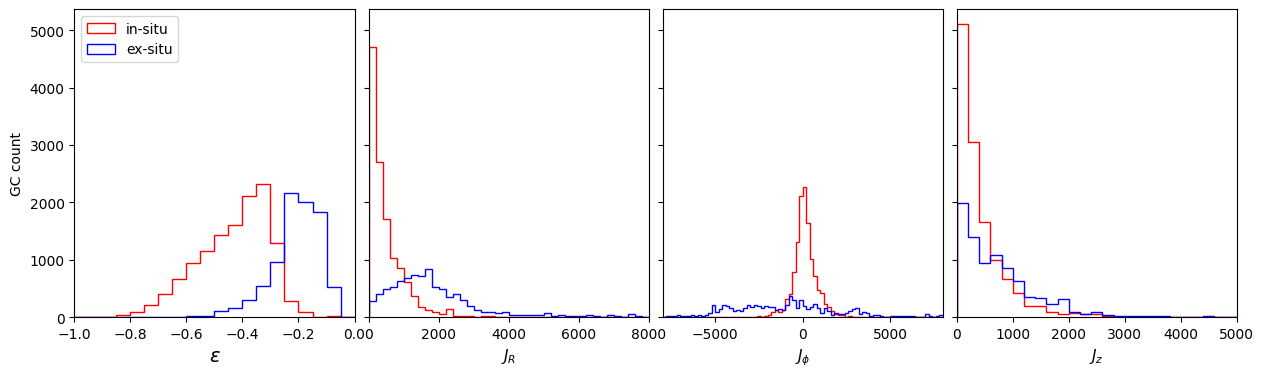

In [115]:
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(15, 4), sharey=True)
plt.subplots_adjust(wspace=0.05)

bins = np.linspace(-1, 0, 21)
axs[0].hist(in_et_norm, color="r", density=False, histtype="step", bins=bins, label="in-situ")
axs[0].hist(ex_et_norm, color="b", density=False, histtype="step", bins=bins, label="ex-situ")
axs[0].set_xlim(-1, 0)
axs[0].set_xlabel(r"$\epsilon$", fontsize=14)

bins = np.linspace(0, 10000, 51)
axs[1].hist(in_jr, color="r", density=False, histtype="step", bins=bins)
axs[1].hist(ex_jr, color="b", density=False, histtype="step", bins=bins)
axs[1].set_xlim(0, 8000)
axs[1].set_xlabel(r"$J_{R}$", fontsize=11)

bins = np.linspace(-10000, 10000, 101)
axs[2].hist(in_jp, color="r", density=False, histtype="step", bins=bins)
axs[2].hist(ex_jp, color="b", density=False, histtype="step", bins=bins)
axs[2].set_xlim(-8000, 8000)
axs[2].set_xlabel(r"$J_{\phi}$", fontsize=11)

bins = np.linspace(0, 5000, 26)
axs[3].hist(in_jz, color="r", density=False, histtype="step", bins=bins)
axs[3].hist(ex_jz, color="b", density=False, histtype="step", bins=bins)
axs[3].set_xlim(0, 5000)
axs[3].set_xlabel(r"$J_{z}$", fontsize=11)

axs[0].legend(loc="upper left")
axs[0].set_ylabel("GC count", fontsize=10)

plt.show()

In [116]:
grp_file = sim_dir + sim + "/" + "gc_groups.json"
with open(grp_file, "r") as file:
    grp_dict = json.load(file)

ex_grp_lst = np.array([int(grp) for grp in grp_dict[sim].keys() if int(grp) != 0])
ex_grp_lst

array([ 1920378,  4414957,  8580896, 13687078, 16199669, 19898495])

In [117]:
kin_dict = {
    grp: {"et_norm": np.array([]), "jr": np.array([]), "jp": np.array([]), "jz": np.array([])}
    for grp in ex_grp_lst
}

In [118]:
for grp in ex_grp_lst:
    for it_id in proc_data.keys():
        snp_dat = proc_data[it_id]["snapshots"]["snap600"]
        grp_msk = snp_dat["group_id"][()] == grp
        et_norm = snp_dat["et_norm"][grp_msk]
        jcyl = snp_dat["j.cyl"][grp_msk]
        jr = jcyl[:, 0]
        jp = jcyl[:, 1]
        jz = jcyl[:, 2]

        kin_dict[grp]["et_norm"] = np.concatenate((kin_dict[grp]["et_norm"], et_norm))
        kin_dict[grp]["jr"] = np.concatenate((kin_dict[grp]["jr"], jr))
        kin_dict[grp]["jp"] = np.concatenate((kin_dict[grp]["jp"], jp))
        kin_dict[grp]["jz"] = np.concatenate((kin_dict[grp]["jz"], jz))


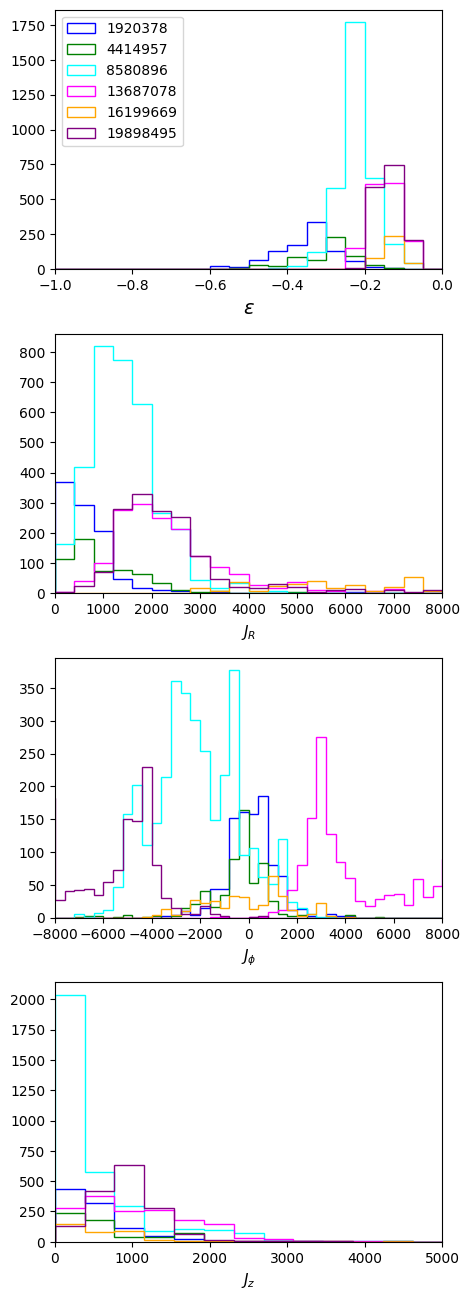

In [120]:
density = False

fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(5, 16))
plt.subplots_adjust(hspace=0.25)

bins = np.linspace(-1, 0, 21)
for grp in ex_grp_lst:
    col = grp_dict[sim][str(grp)]
    axs[0].hist(kin_dict[grp]["et_norm"], density=density, histtype="step", color=col, bins=bins, label=grp)
axs[0].set_xlim(-1, 0)
axs[0].set_xlabel(r"$\epsilon$", fontsize=14)


bins = np.linspace(0, 10000, 26)
for grp in ex_grp_lst:
    col = grp_dict[sim][str(grp)]
    axs[1].hist(kin_dict[grp]["jr"], density=density, histtype="step", color=col, bins=bins)
axs[1].set_xlim(0, 8000)
axs[1].set_xlabel(r"$J_{R}$", fontsize=11)


bins = np.linspace(-10000, 10000, 51)
for grp in ex_grp_lst:
    col = grp_dict[sim][str(grp)]
    axs[2].hist(kin_dict[grp]["jp"], density=density, histtype="step", color=col, bins=bins)
axs[2].set_xlim(-8000, 8000)
axs[2].set_xlabel(r"$J_{\phi}$", fontsize=11)

bins = np.linspace(0, 5000, 14)
for grp in ex_grp_lst:
    col = grp_dict[sim][str(grp)]
    axs[3].hist(kin_dict[grp]["jz"], density=density, histtype="step", color=col, bins=bins)
axs[3].set_xlim(0, 5000)
axs[3].set_xlabel(r"$J_{z}$", fontsize=11)

axs[0].legend(loc="upper left")
